<a href="https://colab.research.google.com/github/matoscx/Clustering-de-Estudiantes-Desempe-o-Acad-mico/blob/main/Clustering_de_Estudiantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Clustering de Estudiantes — Desempeño Académico.*

**Dataset:** [Student Performance Dataset - UCI Machine Learning Repository](https://www.kaggle.com/datasets/dskagglemt/student-performance-data-set)


#Instalación e Importación de Librerías

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Carga y Exploracion Inicial del dataset de Student Performance de la UCI.


In [ ]:
# Cargamos el dataset de Student Performance de UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip'
import urllib.request
import zipfile
import os

# Descargamos y extraemos el dataset
print("Descargando dataset...")
urllib.request.urlretrieve(url, 'student.zip')
with zipfile.ZipFile('student.zip', 'r') as zip_ref:
    zip_ref.extractall('student_data')

# Cargamos el dataset (https://www.kaggle.com/datasets/dskagglemt/student-performance-data-set?select=student-mat.csv)
df = pd.read_csv('student_data/student-por.csv', sep=';')

print("Dataset cargado exitosamente")
print(f"Dimensiones del dataset: {df.shape}")

Descargando dataset...
Dataset cargado exitosamente
Dimensiones del dataset: (649, 33)


#Análisis Inicial y Comprensión de los Datos.


In [ ]:
# Análisis inicial
print("#" * 57)
print("ANÁLISIS INICIAL DEL DATASET CLUSTERING DE ESTUDIANTES.")
print("#" * 57)

# Información básica
print(f"Número de estudiantes: {len(df)}")
print(f"Número de variables: {len(df.columns)}")

# Primer vistazo a los datos
print("\nPrimeras 5 filas del dataset:")
print(df.head())

# Información de tipos de datos
print("\nInformación de tipos de datos:")
print(df.info())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

#########################################################
ANÁLISIS INICIAL DEL DATASET CLUSTERING DE ESTUDIANTES.
#########################################################
Número de estudiantes: 649
Número de variables: 33

Primeras 5 filas del dataset:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        4   0  11  11  
1      5        3      3     1     1      3        2   9  11  11  
2      4        3      2     2     3      3        6  12  

#Identificación de Variables y Estructura.

In [ ]:
# Separamos variables numéricas y categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("VARIABLES IDENTIFICADAS:")
print(f"# Numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"# Categóricas ({len(categorical_cols)}): {categorical_cols}")

# Descripción de categorías de variables
variables_categories = {
    'Demográficas': ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus'],
    'Familiares': ['Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian'],
    'Sociales': ['famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic'],
    'Académicas': ['traveltime', 'studytime', 'failures', 'schoolsup', 'absences'],
    'Notas': ['G1', 'G2', 'G3']
}

print("\nCATEGORÍAS DE VARIABLES:")
for categoria, variables in variables_categories.items():
    print(f"# {categoria}: {variables}")

VARIABLES IDENTIFICADAS:
# Numéricas (16): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
# Categóricas (17): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

CATEGORÍAS DE VARIABLES:
# Demográficas: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus']
# Familiares: ['Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian']
# Sociales: ['famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
# Académicas: ['traveltime', 'studytime', 'failures', 'schoolsup', 'absences']
# Notas: ['G1', 'G2', 'G3']


# Limpieza y tratamiento de valores faltantes.

In [ ]:
print("#" * 70)
print("LIMPIEZA Y TRATAMIENTO DE VALORES FALTANTES CLUSTERING DE ESTUDIANTES")
print("#" * 70)

# Identificación de valores nulos
print("Buscando valores nulos...")
null_analysis = df.isnull().sum()
null_variables = null_analysis[null_analysis > 0]

if len(null_variables) == 0:
    print("No se encontraron valores nulos en el dataset")
else:
    print(f"Se encontraron valores nulos en {len(null_variables)} variables:")
    for var, count in null_variables.items():
        print(f"   - {var}: {count} valores nulos ({count/len(df)*100:.2f}%)")

# Identificación de valores inconsistentes o problemáticos
print("\nAnalizando valores problemáticos...")
for col in df.columns:
    if df[col].dtype == 'object':
        unique_vals = df[col].unique()
        if len(unique_vals) < 10:  # Mostrar solo variables con pocos valores únicos
            print(f"   # {col}: {unique_vals}")

# Verificación de duplicados
duplicados = df.duplicated().sum()
print(f"\nDuplicados encontrados: {duplicados}")
if duplicados > 0:
    df = df.drop_duplicates()
    print(f"Duplicados eliminados. Nuevo tamaño: {df.shape}")

print("Limpieza de datos completada")

######################################################################
LIMPIEZA Y TRATAMIENTO DE VALORES FALTANTES CLUSTERING DE ESTUDIANTES
######################################################################
Buscando valores nulos...
No se encontraron valores nulos en el dataset

Analizando valores problemáticos...
   # school: ['GP' 'MS']
   # sex: ['F' 'M']
   # address: ['U' 'R']
   # famsize: ['GT3' 'LE3']
   # Pstatus: ['A' 'T']
   # Mjob: ['at_home' 'health' 'other' 'services' 'teacher']
   # Fjob: ['teacher' 'other' 'services' 'health' 'at_home']
   # reason: ['course' 'other' 'home' 'reputation']
   # guardian: ['mother' 'father' 'other']
   # schoolsup: ['yes' 'no']
   # famsup: ['no' 'yes']
   # paid: ['no' 'yes']
   # activities: ['no' 'yes']
   # nursery: ['yes' 'no']
   # higher: ['yes' 'no']
   # internet: ['no' 'yes']
   # romantic: ['no' 'yes']

Duplicados encontrados: 0
Limpieza de datos completada


# Análisis Exploratorio (EDA) - estadísticas descriptivas.

In [ ]:
print("#" * 57)
print("ANÁLISIS EXPLORATORIO (EDA) - ESTADÍSTICAS DESCRIPTIVAS")
print("#" * 57)

# Análisis de variables numéricas clave
variables_clave = ['age', 'Medu', 'Fedu', 'studytime', 'failures', 'absences', 'G1', 'G2', 'G3']

print("\nESTADÍSTICAS DE VARIABLES CLAVE:")
stats_df = df[variables_clave].describe()
print(stats_df)

# Análisis de distribuciones de variables categóricas importantes
categoricas_clave = ['sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'higher']

print("\nDISTRIBUCIÓN DE VARIABLES CATEGÓRICAS:")
for var in categoricas_clave:
    print(f"\n{var}:")
    print(df[var].value_counts())

#########################################################
ANÁLISIS EXPLORATORIO (EDA) - ESTADÍSTICAS DESCRIPTIVAS
#########################################################

ESTADÍSTICAS DE VARIABLES CLAVE:
              age        Medu        Fedu   studytime    failures    absences  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean    16.744222    2.514638    2.306626    1.930663    0.221880    3.659476   
std      1.218138    1.134552    1.099931    0.829510    0.593235    4.640759   
min     15.000000    0.000000    0.000000    1.000000    0.000000    0.000000   
25%     16.000000    2.000000    1.000000    1.000000    0.000000    0.000000   
50%     17.000000    2.000000    2.000000    2.000000    0.000000    2.000000   
75%     18.000000    4.000000    3.000000    2.000000    0.000000    6.000000   
max     22.000000    4.000000    4.000000    4.000000    3.000000   32.000000   

               G1          G2          G3  
count  649.000000  6

#Análisis exploratorio (EDA) - Gráficos.

########################################
ANÁLISIS EXPLORATORIO (EDA) - GRÁFICOS
########################################


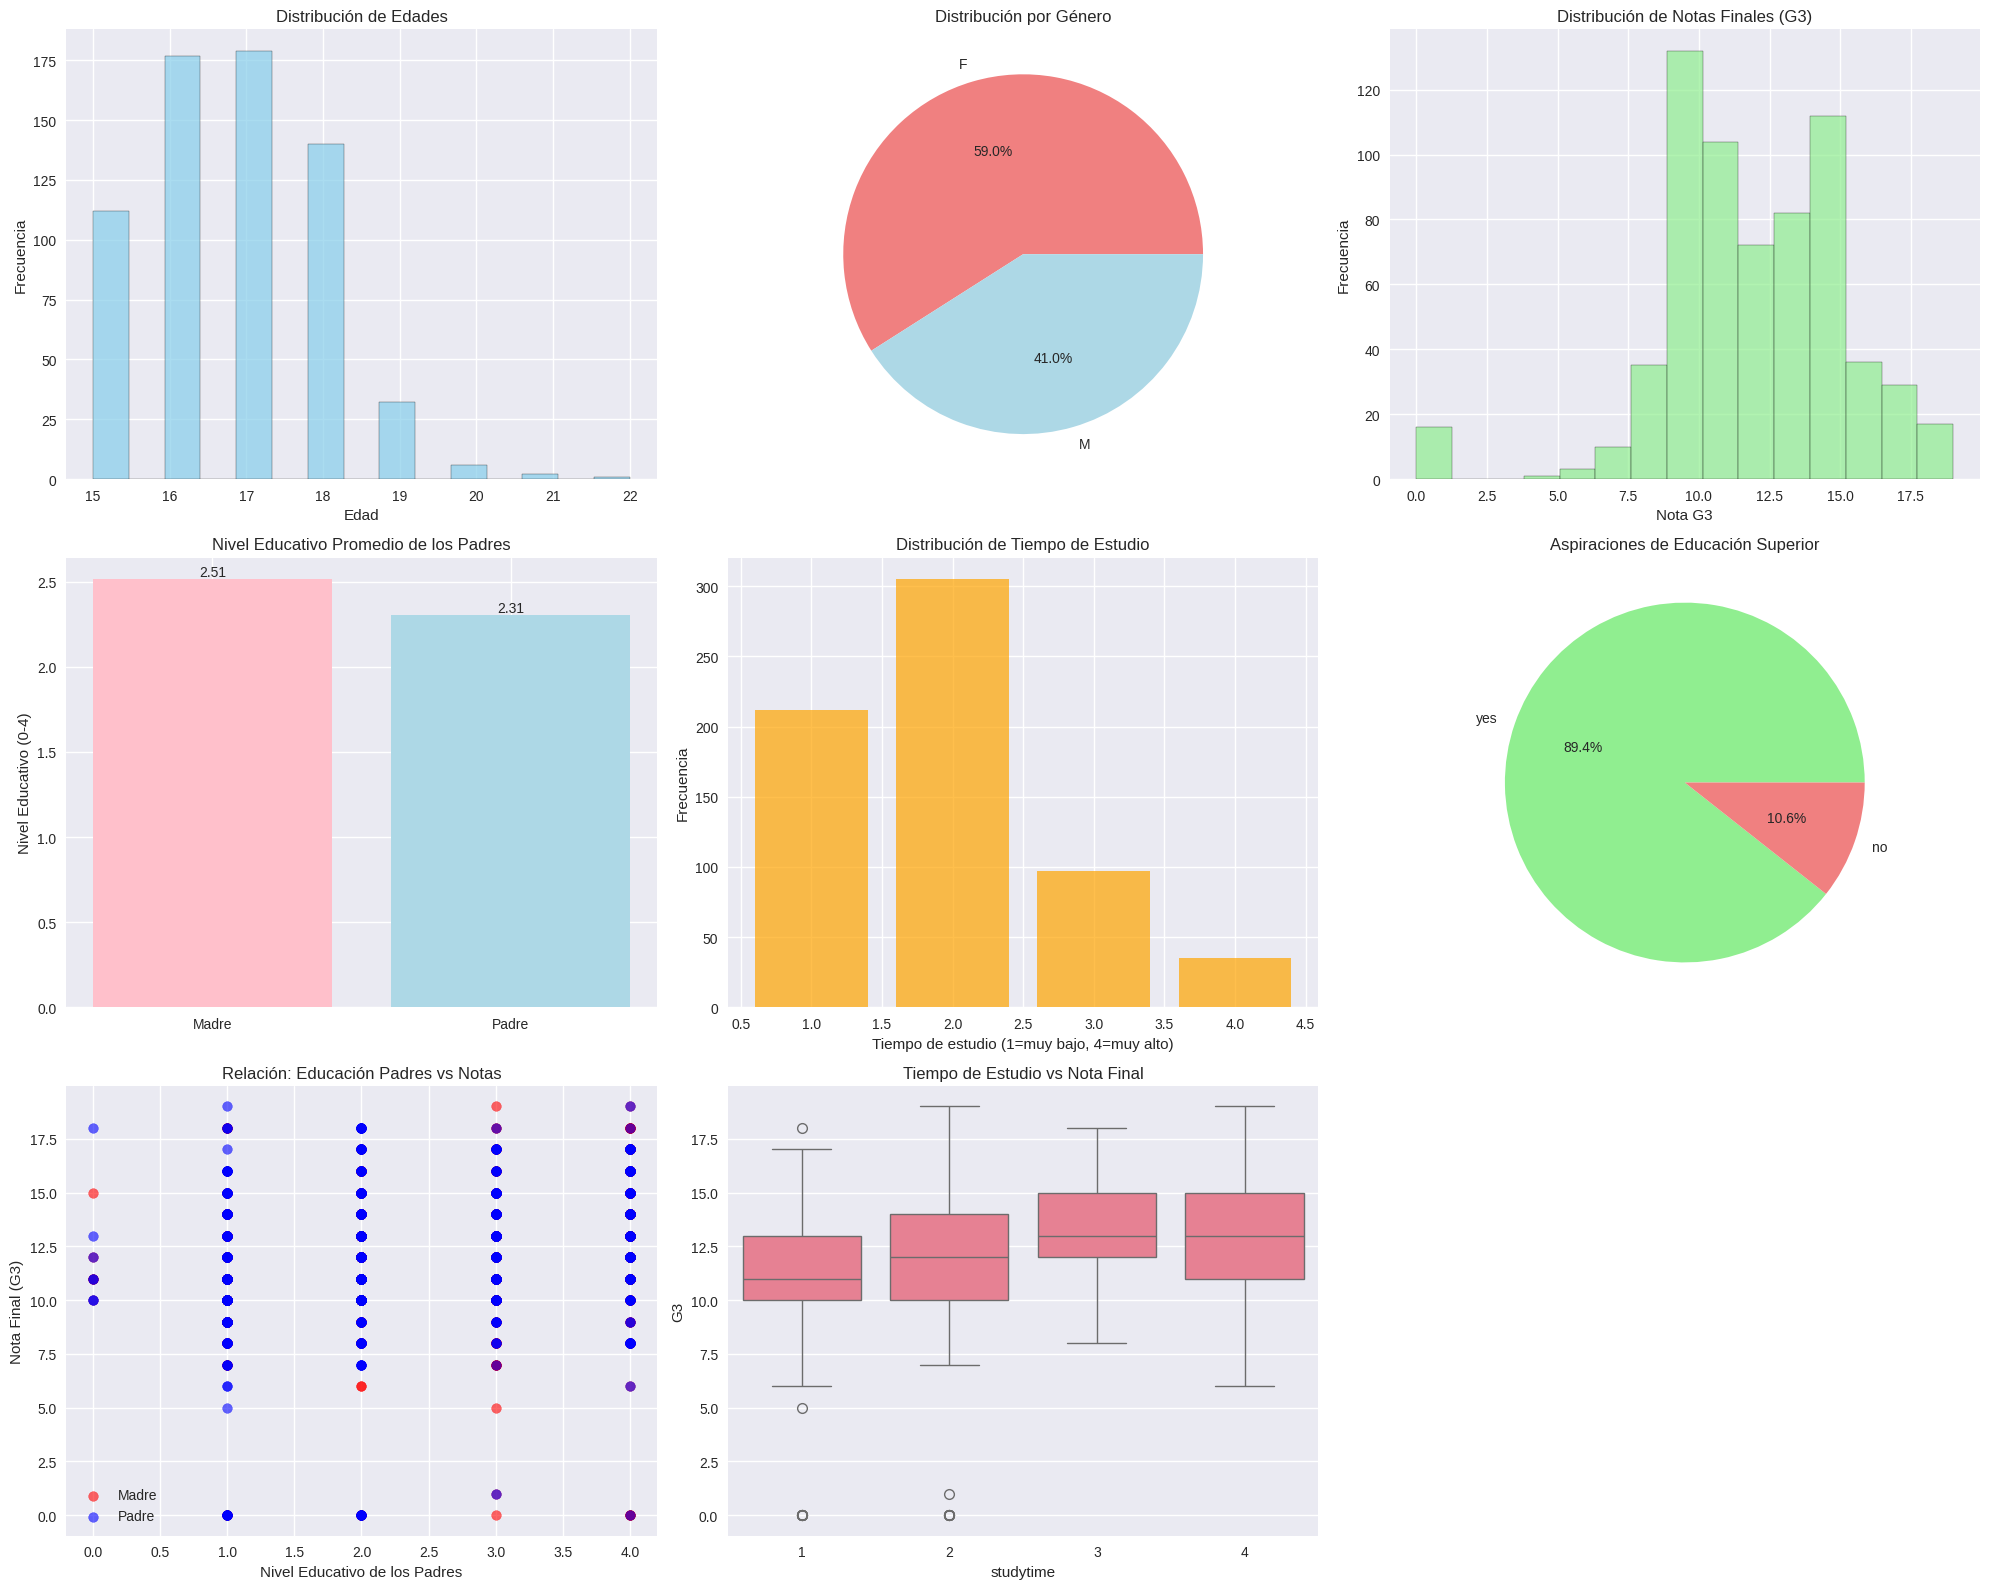

In [ ]:
print("#" * 40)
print("ANÁLISIS EXPLORATORIO (EDA) - GRÁFICOS")
print("#" * 40)

# Configuración de figura para múltiples gráficos
fig = plt.figure(figsize=(20, 16))

# Distribución de edades
plt.subplot(3, 3, 1)
plt.hist(df['age'], bins=15, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

# Distribución de género
plt.subplot(3, 3, 2)
gender_counts = df['sex'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['lightcoral', 'lightblue'])
plt.title('Distribución por Género')

# Distribución de notas finales (G3)
plt.subplot(3, 3, 3)
plt.hist(df['G3'], bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Distribución de Notas Finales (G3)')
plt.xlabel('Nota G3')
plt.ylabel('Frecuencia')

# Educación de los padres
plt.subplot(3, 3, 4)
parent_edu = df[['Medu', 'Fedu']].mean()
bars = plt.bar(['Madre', 'Padre'], parent_edu, color=['pink', 'lightblue'])
plt.title('Nivel Educativo Promedio de los Padres')
plt.ylabel('Nivel Educativo (0-4)')
# Añadir valores en las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}', ha='center', va='bottom')

# Tiempo de estudio
plt.subplot(3, 3, 5)
studytime_counts = df['studytime'].value_counts().sort_index()
plt.bar(studytime_counts.index, studytime_counts.values, color='orange', alpha=0.7)
plt.title('Distribución de Tiempo de Estudio')
plt.xlabel('Tiempo de estudio (1=muy bajo, 4=muy alto)')
plt.ylabel('Frecuencia')

# Aspiraciones de educación superior
plt.subplot(3, 3, 6)
higher_counts = df['higher'].value_counts()
plt.pie(higher_counts.values, labels=higher_counts.index, autopct='%1.1f%%',
        colors=['lightgreen', 'lightcoral'])
plt.title('Aspiraciones de Educación Superior')

# Relación entre educación de padres y notas
plt.subplot(3, 3, 7)
plt.scatter(df['Medu'], df['G3'], alpha=0.6, color='red', label='Madre')
plt.scatter(df['Fedu'], df['G3'], alpha=0.6, color='blue', label='Padre')
plt.xlabel('Nivel Educativo de los Padres')
plt.ylabel('Nota Final (G3)')
plt.title('Relación: Educación Padres vs Notas')
plt.legend()

# Relación entre tiempo de estudio y notas
plt.subplot(3, 3, 8)
sns.boxplot(data=df, x='studytime', y='G3')
plt.title('Tiempo de Estudio vs Nota Final')

plt.tight_layout()
plt.show()


#Analisis de Correlaciones.

########################################
ANÁLISIS DE CORRELACIONES
########################################


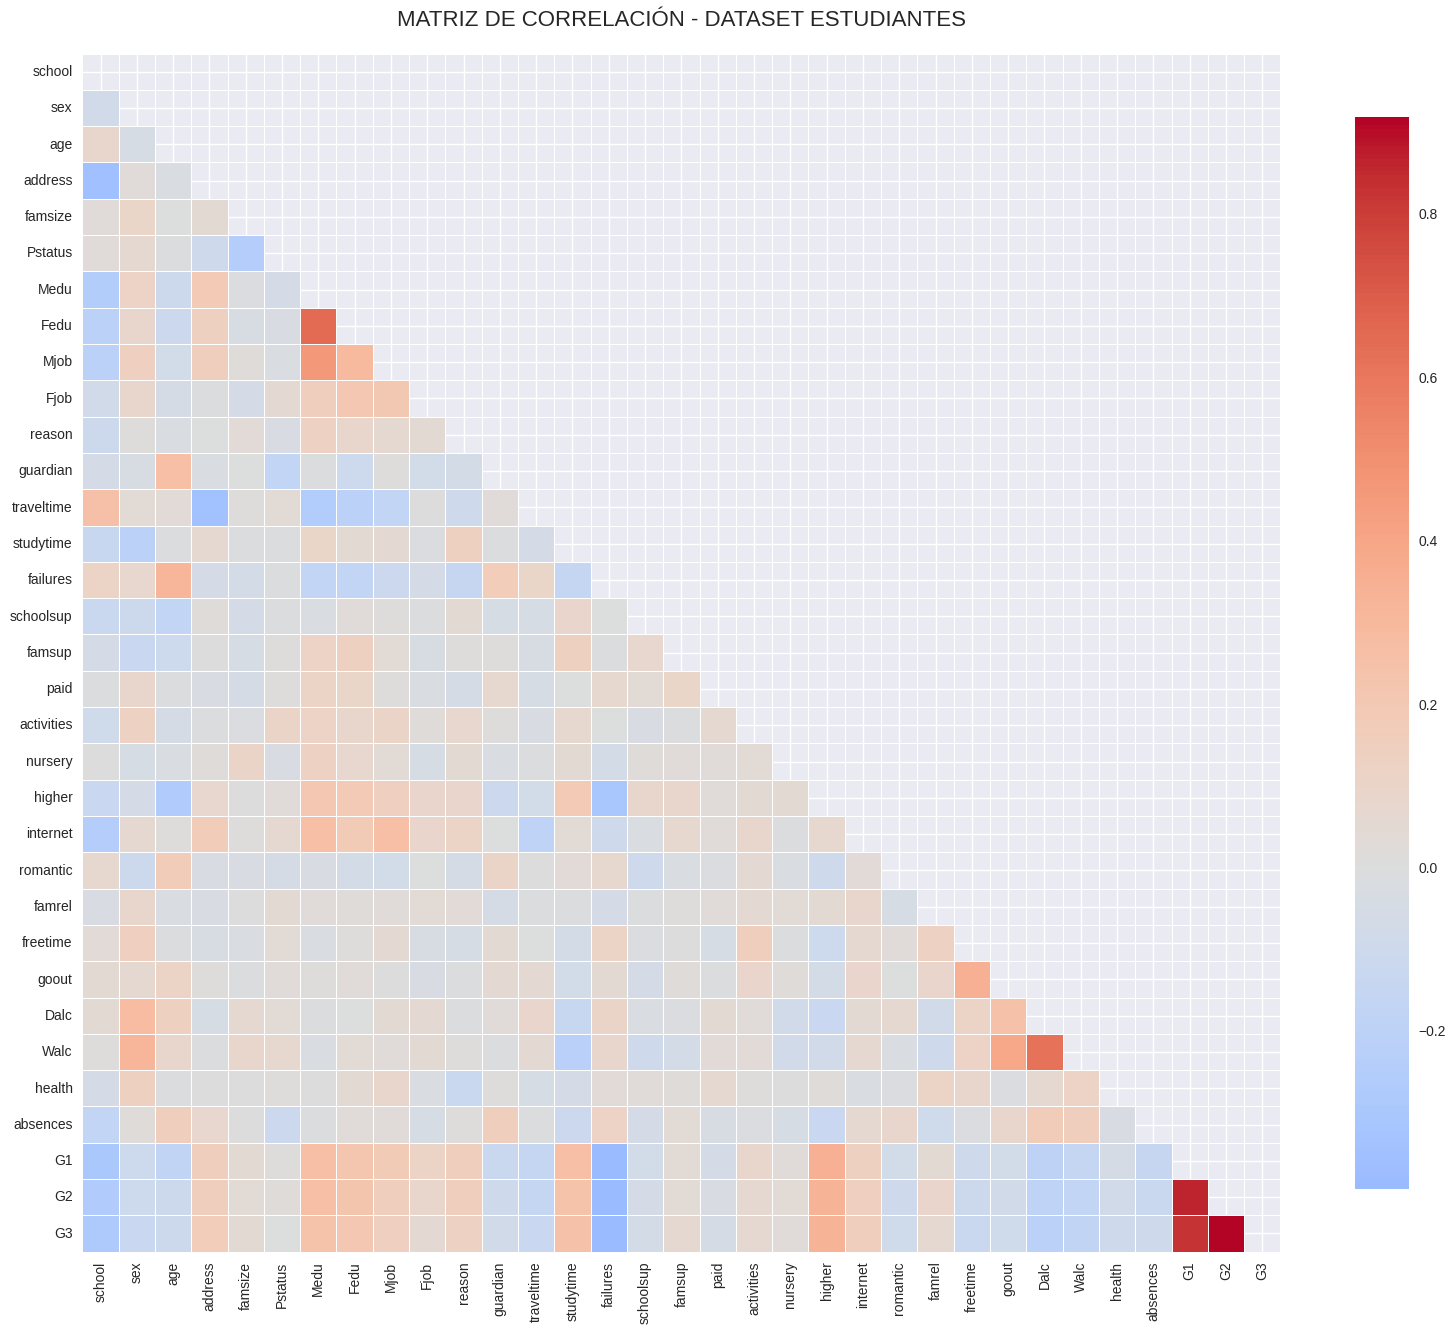

CORRELACIONES CON NOTA FINAL G3:
G3           1.000000
G2           0.918548
G1           0.826387
higher       0.332172
studytime    0.249789
Medu         0.240151
Fedu         0.211800
address      0.167637
internet     0.150025
Mjob         0.148252
Name: G3, dtype: float64

CORRELACIONES NEGATIVAS CON NOTA FINAL G3:
sex        -0.129077
Walc       -0.176619
Dalc       -0.204719
school     -0.284294
failures   -0.393316
Name: G3, dtype: float64


In [ ]:
print("#" * 40)
print("ANÁLISIS DE CORRELACIONES")
print("#" * 40)

# Codificación para análisis de correlación
df_encoded = df.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Matriz de correlación
plt.figure(figsize=(16, 14))
correlation_matrix = df_encoded.corr()

# Heatmap de correlaciones
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=False, cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('MATRIZ DE CORRELACIÓN - DATASET ESTUDIANTES', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Correlaciones más importantes con G3
print("CORRELACIONES CON NOTA FINAL G3:")
g3_correlations = correlation_matrix['G3'].sort_values(ascending=False)
print(g3_correlations.head(10))

print("\nCORRELACIONES NEGATIVAS CON NOTA FINAL G3:")
print(g3_correlations.tail(5))

# Normalización o estandarización de variables numéricas.

#########################################################
NORMALIZACIÓN O ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS
#########################################################

VARIABLES SELECCIONADAS PARA CLUSTERING:
Número de variables: 16
Variables: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Dataset para clustering: (649, 16)
Estandarización completada

ESTADÍSTICAS DESPUÉS DE ESTANDARIZACIÓN:
                age          Medu          Fedu    traveltime     studytime  \
count  6.490000e+02  6.490000e+02  6.490000e+02  6.490000e+02  6.490000e+02   
mean  -1.751723e-16 -1.094827e-16 -3.284481e-17 -7.663789e-17  9.579736e-17   
std    1.000771e+00  1.000771e+00  1.000771e+00  1.000771e+00  1.000771e+00   
min   -1.432980e+00 -2.218124e+00 -2.098682e+00 -7.600319e-01 -1.122808e+00   
25%   -6.114218e-01 -4.539544e-01 -1.188832e+00 -7.600319e-01 -1.122808e+00   
50%    2.101367e-01 -4.

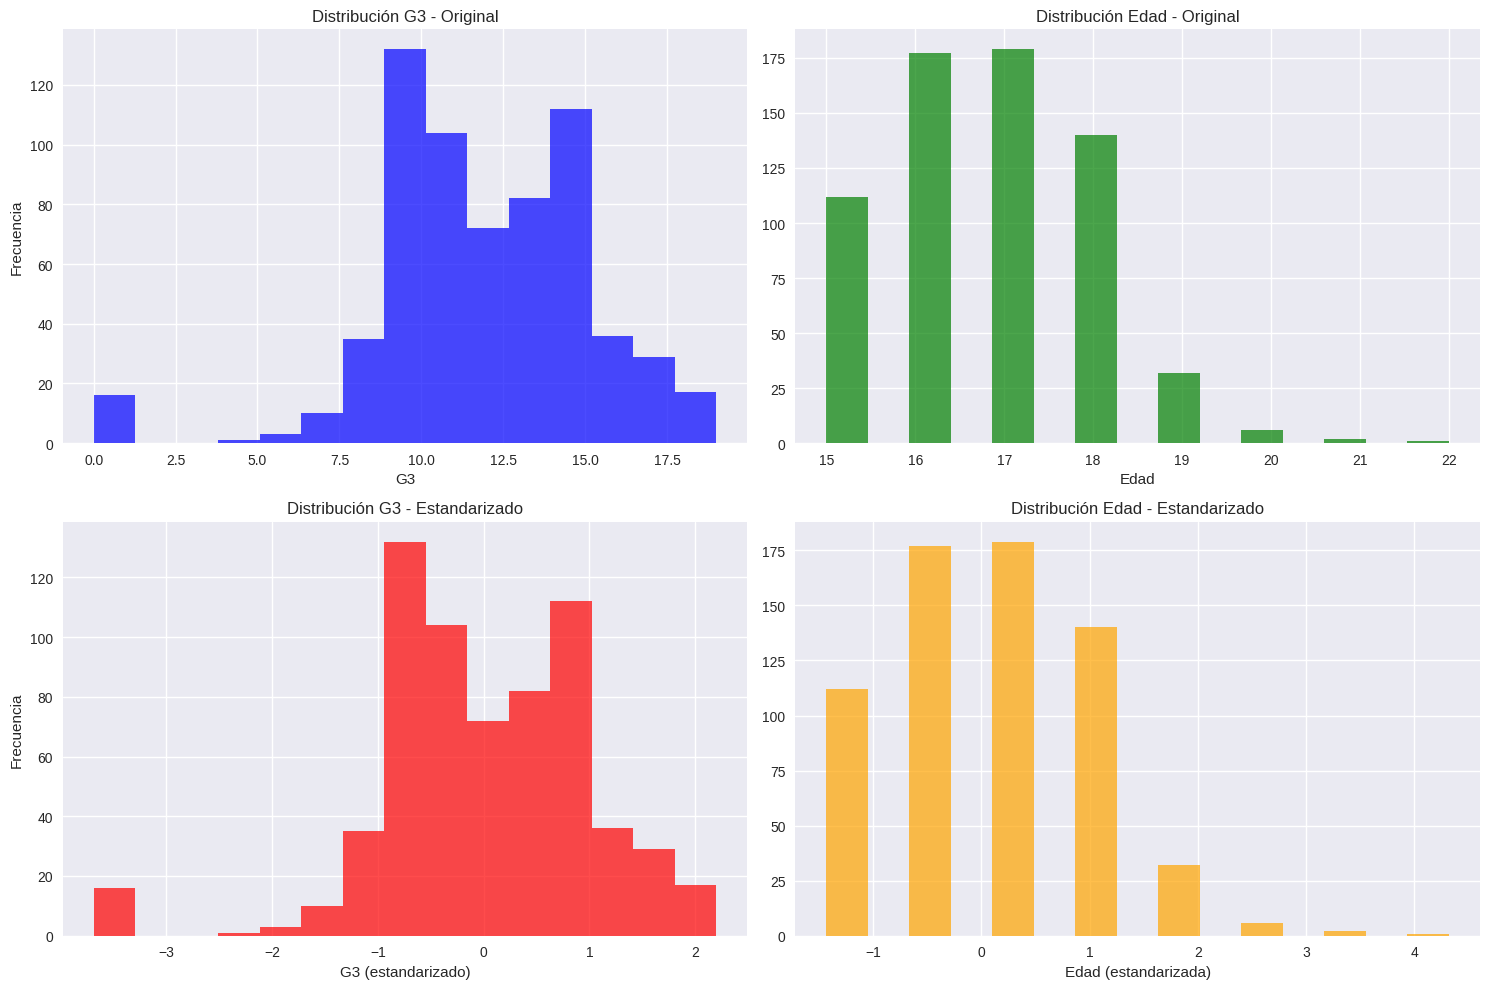

In [ ]:
print("#" * 57)
print("NORMALIZACIÓN O ESTANDARIZACIÓN DE VARIABLES NUMÉRICAS")
print("#" * 57)

# Selección de variables para clustering (basado en el análisis EDA)
variables_para_clustering = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
    'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences',
    'G1', 'G2', 'G3'
]

print("\nVARIABLES SELECCIONADAS PARA CLUSTERING:")
print(f"Número de variables: {len(variables_para_clustering)}")
print(f"Variables: {variables_para_clustering}")

# Crear dataset para clustering
df_clustering = df_encoded[variables_para_clustering].copy()

print(f"\nDataset para clustering: {df_clustering.shape}")

# Estandarización de variables
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_clustering)
df_scaled = pd.DataFrame(df_scaled, columns=variables_para_clustering)

print("Estandarización completada")

# Verificación de la estandarización
print("\nESTADÍSTICAS DESPUÉS DE ESTANDARIZACIÓN:")
print(df_scaled.describe())

# Visualización de distribución antes y después de estandarizar
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Antes de estandarizar
axes[0,0].hist(df_clustering['G3'], bins=15, alpha=0.7, color='blue', label='Original')
axes[0,0].set_title('Distribución G3 - Original')
axes[0,0].set_xlabel('G3')
axes[0,0].set_ylabel('Frecuencia')

axes[0,1].hist(df_clustering['age'], bins=15, alpha=0.7, color='green', label='Original')
axes[0,1].set_title('Distribución Edad - Original')
axes[0,1].set_xlabel('Edad')

# Después de estandarizar
axes[1,0].hist(df_scaled['G3'], bins=15, alpha=0.7, color='red', label='Estandarizado')
axes[1,0].set_title('Distribución G3 - Estandarizado')
axes[1,0].set_xlabel('G3 (estandarizado)')
axes[1,0].set_ylabel('Frecuencia')

axes[1,1].hist(df_scaled['age'], bins=15, alpha=0.7, color='orange', label='Estandarizado')
axes[1,1].set_title('Distribución Edad - Estandarizado')
axes[1,1].set_xlabel('Edad (estandarizada)')

plt.tight_layout()
plt.show()

Aplicar al menos dos métodos de clustering, tales como:

# K-Means

#########################
CLUSTERING CON K-MEANS
#########################
   Cluster_KMeans
0               0
1               0
2               1
3               2
4               2


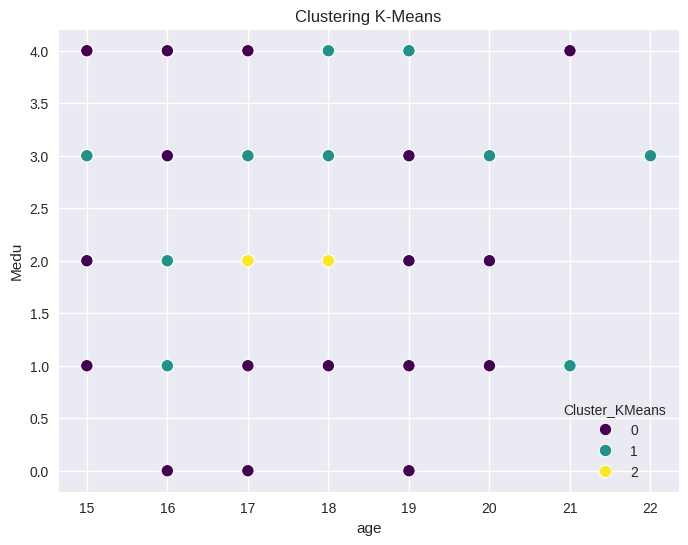

In [ ]:
print("#" * 25)
print("CLUSTERING CON K-MEANS")
print("#" * 25)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

X = df.select_dtypes(include=["int64", "float64"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicamos K-Means con 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Agregamos los resultados al DataFrame original
df["Cluster_KMeans"] = kmeans_labels

# Mostrar las primeras filas con el cluster asignado
print(df[["Cluster_KMeans"]].head())

# ---------------------------------------
# Visualización de los clusters
# ---------------------------------------

if X.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=X.iloc[:, 0],
        y=X.iloc[:, 1],
        hue=df["Cluster_KMeans"],
        palette="viridis",
        s=80
    )
    plt.title("Clustering K-Means")
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.show()
else:
    print("No hay suficientes columnas numéricas para graficar.")



# Gaussian Mixture Models (GMM)

#############################################
CLUSTERING CON GAUSSIAN MIXTURE MODELS (GMM)
#############################################
   Cluster_GMM
0            1
1            0
2            0
3            0
4            0


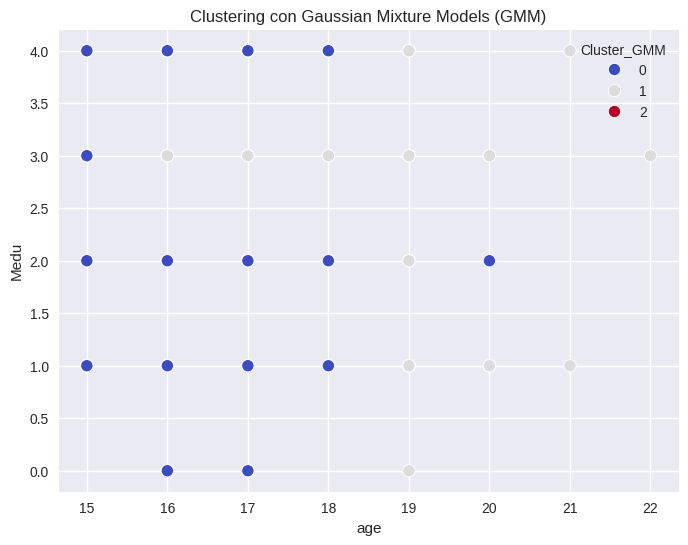

In [ ]:
print("#" * 45)
print("CLUSTERING CON GAUSSIAN MIXTURE MODELS (GMM)")
print("#" * 45)

from sklearn.mixture import GaussianMixture

# Seleccionar nuevamente las columnas numéricas
X = df.select_dtypes(include=["int64", "float64"])

# Escalar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar GMM con 3 componentes
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# Agregamos los resultados de GMM al DataFrame original
df["Cluster_GMM"] = gmm_labels

# Mostramos las primeras filas con los clusters GMM asignados
print(df[["Cluster_GMM"]].head())

# ---------------------------------------
# Visualización de los clusters GMM
# ---------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

# Graficar si hay al menos dos variables numéricas
if X.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=X.iloc[:, 0],
        y=X.iloc[:, 1],
        hue=df["Cluster_GMM"],
        palette="coolwarm",
        s=80
    )
    plt.title("Clustering con Gaussian Mixture Models (GMM)")
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.show()
else:
    print("No hay suficientes columnas numéricas para graficar.")


Evaluar la calidad de los clústeres usando métricas como:
Silhouette Score
Calinski–Harabasz Index
Davies–Bouldin Index


In [ ]:
print("#" * 45)
print("EVALUACIÓN DE LA CALIDAD DE LOS CLÚSTERES")
print("#" * 45)

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Seleccionamos las columnas numéricas nuevamente
X = df.select_dtypes(include=["int64", "float64"])

# Escalamos los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Evaluamos K-Means
sil_kmeans = silhouette_score(X_scaled, df["Cluster_KMeans"])
ch_kmeans = calinski_harabasz_score(X_scaled, df["Cluster_KMeans"])
db_kmeans = davies_bouldin_score(X_scaled, df["Cluster_KMeans"])

# Evaluamos GMM
sil_gmm = silhouette_score(X_scaled, df["Cluster_GMM"])
ch_gmm = calinski_harabasz_score(X_scaled, df["Cluster_GMM"])
db_gmm = davies_bouldin_score(X_scaled, df["Cluster_GMM"])

# Mostramos los resultados en forma de tabla
import pandas as pd

metricas = pd.DataFrame({
    "Métrica": ["Silhouette Score", "Calinski-Harabasz Index", "Davies-Bouldin Index"],
    "K-Means": [sil_kmeans, ch_kmeans, db_kmeans],
    "GMM": [sil_gmm, ch_gmm, db_gmm]
})

print("Evaluación de la calidad de los clústeres:")
display(metricas)


#############################################
EVALUACIÓN DE LA CALIDAD DE LOS CLÚSTERES
#############################################
Evaluación de la calidad de los clústeres:


,Métrica,K-Means,GMM
0,Silhouette Score,0.140055,0.211280
1,Calinski-Harabasz Index,104.995399,72.399233
2,Davies-Bouldin Index,2.161038,1.942166


# Visualizar los resultados

con PCA, t-SNE o mapas de calor.

#############################################
VISUALIZACIÓN DE RESULTADOS CON PCA Y t-SNE
#############################################


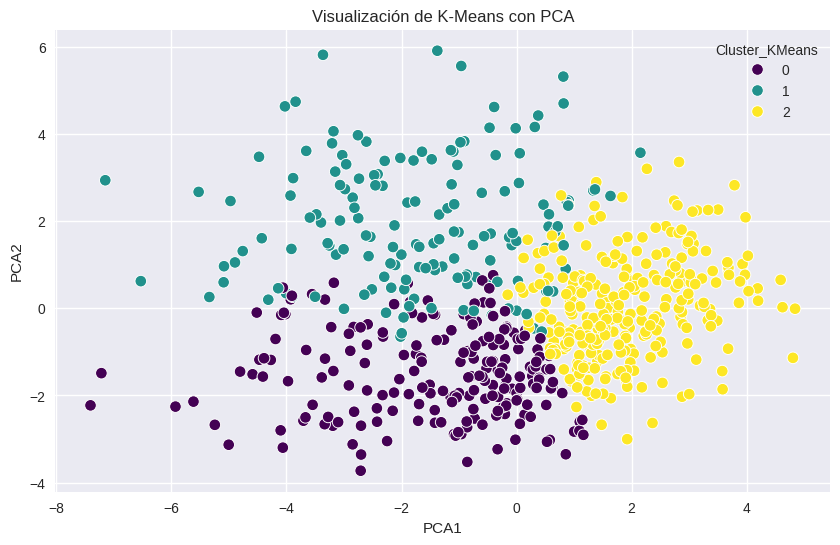

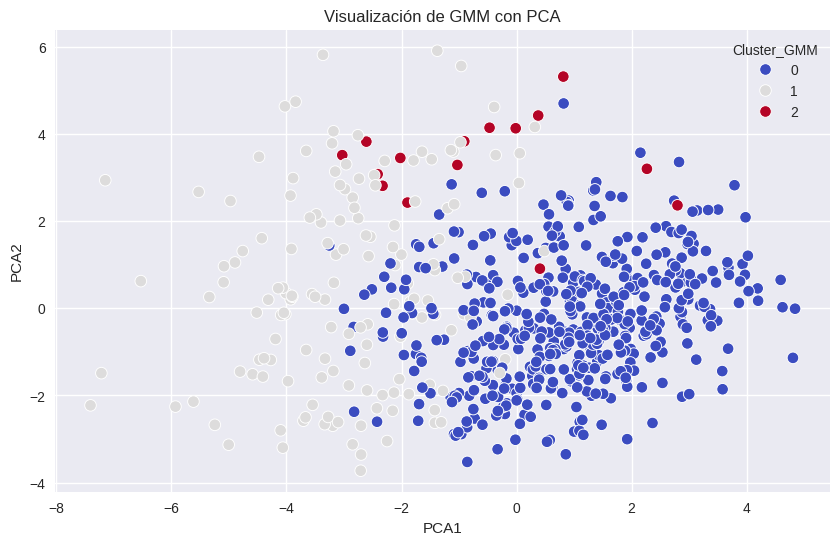

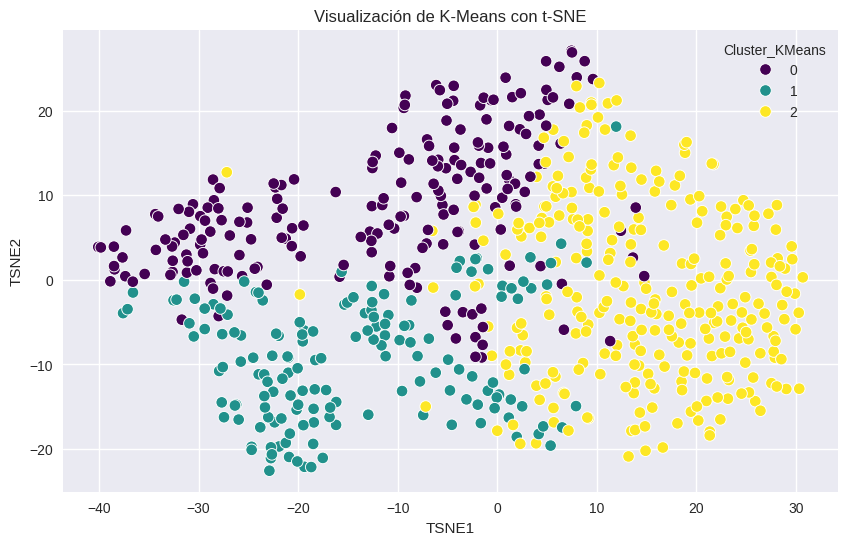

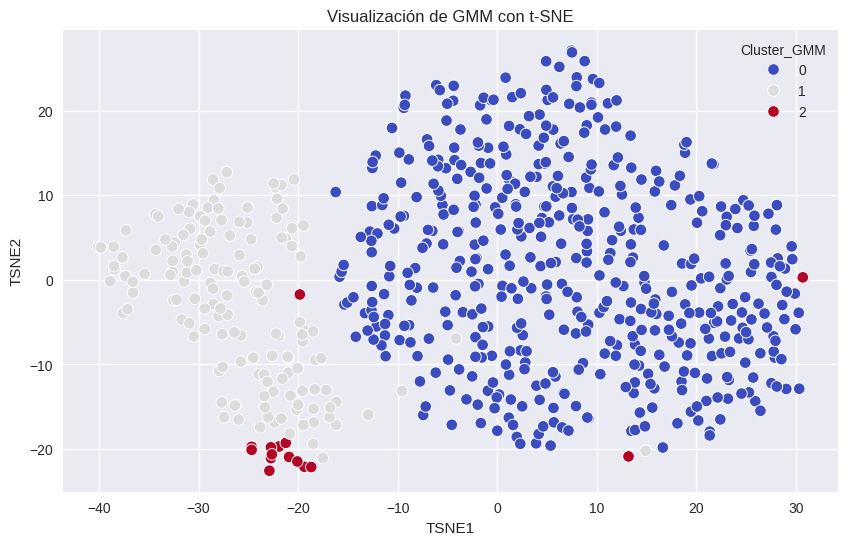

In [ ]:
print("#" * 45)
print("VISUALIZACIÓN DE RESULTADOS CON PCA Y t-SNE")
print("#" * 45)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Escalamos los datos nuevamente (por si acaso)
X = df.select_dtypes(include=["int64", "float64"])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------
# PCA (reducción a 2 dimensiones)
# ---------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="PCA1", y="PCA2", hue="Cluster_KMeans",
    data=df, palette="viridis", s=70
)
plt.title("Visualización de K-Means con PCA")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="PCA1", y="PCA2", hue="Cluster_GMM",
    data=df, palette="coolwarm", s=70
)
plt.title("Visualización de GMM con PCA")
plt.show()

# ---------------------------------------
# t-SNE (reducción no lineal para mayor separación visual)
# ---------------------------------------
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

df["TSNE1"] = X_tsne[:, 0]
df["TSNE2"] = X_tsne[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="TSNE1", y="TSNE2", hue="Cluster_KMeans",
    data=df, palette="viridis", s=70
)
plt.title("Visualización de K-Means con t-SNE")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x="TSNE1", y="TSNE2", hue="Cluster_GMM",
    data=df, palette="coolwarm", s=70
)
plt.title("Visualización de GMM con t-SNE")
plt.show()
